<IPython.core.display.Javascript object>


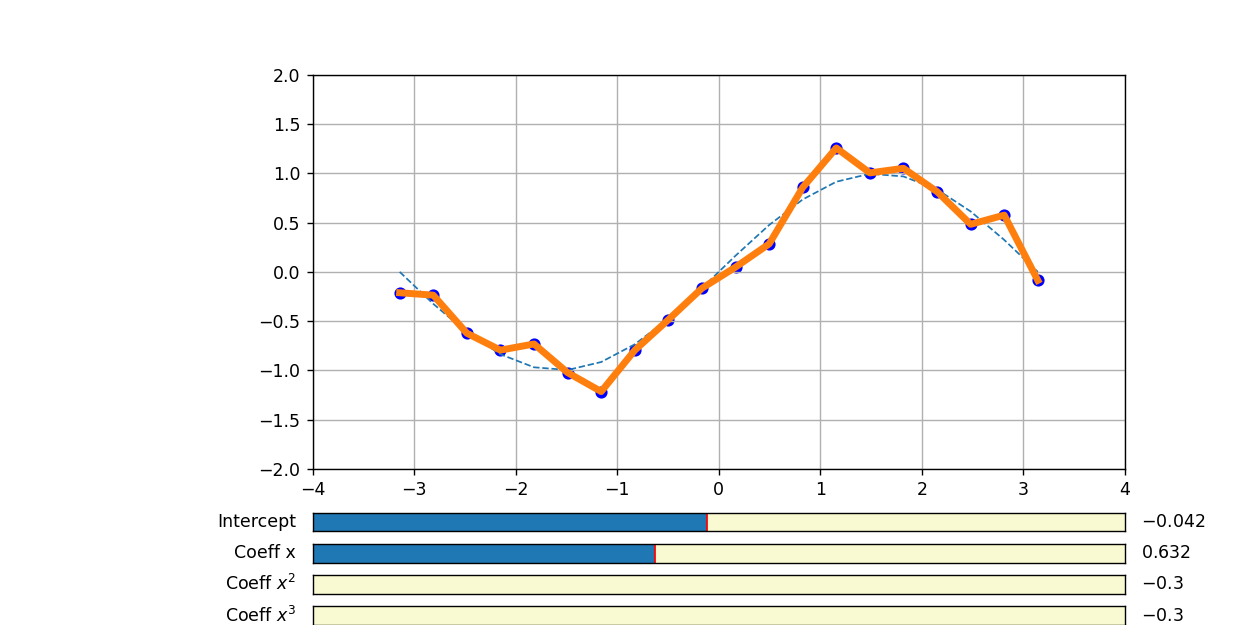

In [5]:
# pip install ipywidgets (in prealabil)
# jupyter nbextension enable --py --sys-prefix widgetsnbextension (cu sudo)
#
# reopen page and run this frame first

%matplotlib notebook

import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
from ipywidgets import *
import statsmodels.api as sm
from matplotlib.widgets import Slider

x = np.linspace(-np.pi, np.pi, 20)
yideal = np.sin(x)
y = yideal + np.random.randn(len(x))/5

xext = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10,
             x**11, x**12, x**13, x**14, x**15, x**16, x**17, x**18, x**19, x**20]
xext = sm.add_constant(xext)

lm = sm.OLS(y, xext).fit()
f = lambda x: np.dot(xext, lm.params)
yregr = f(x)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.subplots_adjust(left=0.25, bottom=0.25)
ax.plot(x, yideal, lw=1, ls='--')
ax.scatter(x, y, c='b')
[regr] = ax.plot(x, yregr, lw=4)
ax.grid(True)

plt.axis([-4, 4, -2, 2])

axcolor = 'lightgoldenrodyellow'
ax_a = plt.axes([0.25, 0.15, 0.65, 0.03], facecolor=axcolor)
ax_b = plt.axes([0.25, 0.1, 0.65, 0.03], facecolor=axcolor)
ax_c = plt.axes([0.25, 0.05, 0.65, 0.03], facecolor=axcolor)
ax_d = plt.axes([0.25, 0.0, 0.65, 0.03], facecolor=axcolor)

s_a = Slider(ax_a, 'Intercept', -1.5, 1.5, valinit=lm.params[0])
s_b = Slider(ax_b, 'Coeff x', 0, 1.5, valinit=lm.params[1])
s_c = Slider(ax_c, 'Coeff $x^2$', -0.3, 0.3, valinit=lm.params[2])
s_d = Slider(ax_d, 'Coeff $x^3$', -0.3, 0.3, valinit=lm.params[2])

def update(val):
    lm.params[0] = s_a.val
    lm.params[1] = s_b.val
    lm.params[2] = s_c.val
    lm.params[3] = s_d.val
    
    f = lambda x: np.dot(xext, lm.params)
    yregr = f(x)
    regr.set_ydata(yregr)        
    fig.canvas.draw_idle()

s_a.on_changed(update)
s_b.on_changed(update)
s_c.on_changed(update)
s_d.on_changed(update)
plt.show()

In [3]:
lm.params[3]

-0.08833598982800395